# Laboratorio 9: Simulación del álbum de estampas  
## Etapas 5

**Curso:** MM3014 Teoría de Probabilidades  
**Integrantes:**  
- Esteban de la Peña — 24171  
- Martin Villatoro — 24033  

En esta parte del laboratorio formulamos cinco preguntas propias sobre la simulación del álbum. La idea fue no copiar literalmente las preguntas de los laboratorios anteriores, sino usar la misma lógica de simulación para analizar situaciones más concretas: costo, intercambio, presupuesto, compra por cajas y avance parcial del álbum.


## Configuración general

Usaremos un álbum de **980 estampas**, sobres de **7 estampas**, precio por sobre de **Q9.50**, cajas de **104 sobres** y precio por caja de **Q975.00**.  

Para el intercambio no vamos a usar un modelo perfecto donde cada grupo de repetidas siempre se convierte en una faltante, porque eso baja demasiado los resultados. En su lugar, usamos un modelo más realista:

- Cada **50 repetidas** permiten intentar un intercambio.
- El intercambio tiene **35% de probabilidad de ser útil**, es decir, de conseguir una estampa que realmente falta.

Esto hace que el intercambio ayude, pero sin volver la simulación exageradamente optimista.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Parámetros principales del álbum
N = 980                 # estampas distintas del álbum
S = 7                   # estampas por sobre
PRECIO_SOBRE = 9.50     # precio de un sobre en quetzales
SOBRES_POR_CAJA = 104   # sobres por caja
PRECIO_CAJA = 975.00    # precio de una caja en quetzales

# Parámetros de simulación
SEMILLA = 24033
R_COMPLETAR = 1000
R_PRESUPUESTO = 1200
R_90 = 1200

# Parámetros del intercambio realista
K_INTERCAMBIO = 50
P_EXITO_INTERCAMBIO = 0.35

def crear_estado_album(n=N):
    """Crea el estado inicial del álbum."""
    tengo = np.zeros(n, dtype=bool)
    faltantes = list(range(n))
    posicion = np.arange(n, dtype=int)
    return tengo, faltantes, posicion

def marcar_obtenida(estampa, tengo, faltantes, posicion):
    """Marca una estampa como obtenida y la elimina de la lista de faltantes."""
    if tengo[estampa]:
        return

    tengo[estampa] = True
    idx = posicion[estampa]
    ultima = faltantes[-1]
    faltantes[idx] = ultima
    posicion[ultima] = idx
    faltantes.pop()

def agregar_faltante_aleatoria(rng, tengo, faltantes, posicion):
    """Agrega una estampa faltante aleatoria al álbum."""
    if len(faltantes) == 0:
        return None

    idx = rng.integers(0, len(faltantes))
    estampa = faltantes[idx]
    marcar_obtenida(estampa, tengo, faltantes, posicion)
    return estampa

def aplicar_intercambio(rng, tengo, faltantes, posicion, repetidas, k=K_INTERCAMBIO, p_exito=P_EXITO_INTERCAMBIO):
    """
    Modelo de intercambio realista.

    Por cada k repetidas se intenta un intercambio.
    Solo con probabilidad p_exito el intercambio da una estampa faltante.
    """
    intercambios_exitosos = 0
    intentos = 0

    while repetidas >= k and len(faltantes) > 0:
        repetidas -= k
        intentos += 1

        if rng.random() < p_exito:
            agregar_faltante_aleatoria(rng, tengo, faltantes, posicion)
            intercambios_exitosos += 1

    return repetidas, intercambios_exitosos, intentos

def simular_hasta_completar(con_intercambio=False, rng=None, max_sobres=10000):
    """Simula la compra de sobres hasta completar el álbum."""
    if rng is None:
        rng = np.random.default_rng()

    tengo, faltantes, posicion = crear_estado_album(N)
    repetidas = 0
    sobres = 0
    intercambios_exitosos = 0
    intentos_intercambio = 0

    while len(faltantes) > 0 and sobres < max_sobres:
        paquete = rng.integers(0, N, size=S)
        sobres += 1

        for estampa in paquete:
            if tengo[estampa]:
                repetidas += 1
            else:
                marcar_obtenida(estampa, tengo, faltantes, posicion)

        if con_intercambio:
            repetidas, nuevos_exitos, nuevos_intentos = aplicar_intercambio(
                rng, tengo, faltantes, posicion, repetidas
            )
            intercambios_exitosos += nuevos_exitos
            intentos_intercambio += nuevos_intentos

    distintas = N - len(faltantes)
    return {
        "sobres": sobres,
        "distintas": distintas,
        "repetidas_finales": repetidas,
        "completo": distintas == N,
        "intercambios_exitosos": intercambios_exitosos,
        "intentos_intercambio": intentos_intercambio
    }

def simular_con_presupuesto(sobres_disponibles, con_intercambio=False, rng=None):
    """Simula cuántas estampas distintas se logran con una cantidad fija de sobres."""
    if rng is None:
        rng = np.random.default_rng()

    tengo, faltantes, posicion = crear_estado_album(N)
    repetidas = 0
    intercambios_exitosos = 0
    intentos_intercambio = 0

    for _ in range(sobres_disponibles):
        paquete = rng.integers(0, N, size=S)

        for estampa in paquete:
            if tengo[estampa]:
                repetidas += 1
            else:
                marcar_obtenida(estampa, tengo, faltantes, posicion)

        if con_intercambio:
            repetidas, nuevos_exitos, nuevos_intentos = aplicar_intercambio(
                rng, tengo, faltantes, posicion, repetidas
            )
            intercambios_exitosos += nuevos_exitos
            intentos_intercambio += nuevos_intentos

    distintas = N - len(faltantes)
    return {
        "sobres": sobres_disponibles,
        "distintas": distintas,
        "faltantes": len(faltantes),
        "repetidas_finales": repetidas,
        "completo": distintas == N,
        "intercambios_exitosos": intercambios_exitosos,
        "intentos_intercambio": intentos_intercambio
    }

def simular_hasta_porcentaje(porcentaje=0.90, con_intercambio=False, rng=None, max_sobres=10000):
    """Simula cuántos sobres se necesitan para alcanzar cierto porcentaje del álbum."""
    if rng is None:
        rng = np.random.default_rng()

    objetivo = math.ceil(N * porcentaje)
    tengo, faltantes, posicion = crear_estado_album(N)
    repetidas = 0
    sobres = 0
    intercambios_exitosos = 0

    while (N - len(faltantes)) < objetivo and sobres < max_sobres:
        paquete = rng.integers(0, N, size=S)
        sobres += 1

        for estampa in paquete:
            if tengo[estampa]:
                repetidas += 1
            else:
                marcar_obtenida(estampa, tengo, faltantes, posicion)

        if con_intercambio:
            repetidas, nuevos_exitos, _ = aplicar_intercambio(
                rng, tengo, faltantes, posicion, repetidas
            )
            intercambios_exitosos += nuevos_exitos

    distintas = N - len(faltantes)
    return {
        "sobres": sobres,
        "distintas": distintas,
        "porcentaje": distintas / N,
        "intercambios_exitosos": intercambios_exitosos
    }

def resumen_serie(datos):
    """Devuelve media, desviación estándar e intervalo de confianza al 95%."""
    datos = np.array(datos)
    media = datos.mean()
    desv = datos.std(ddof=1)
    error = 1.96 * desv / np.sqrt(len(datos))
    return media, desv, media - error, media + error

def costo_sueltos(sobres):
    return sobres * PRECIO_SOBRE

def costo_por_cajas(sobres):
    return math.ceil(sobres / SOBRES_POR_CAJA) * PRECIO_CAJA


# Pregunta 1  
## ¿Cuántos sobres y cuánto dinero se necesitan en promedio para completar el álbum del Mundial 2026 sin realizar intercambios?

Esta pregunta nos sirve como punto de comparación. Primero vemos qué pasa si una persona intenta llenar el álbum solo comprando sobres, sin pedir, vender o intercambiar estampas repetidas.


,Métrica,Resultado
0,Sobres promedio para completar,1035.307000
1,Desviación estándar de sobres,175.144278
2,Límite inferior IC 95%,1024.451445
3,Límite superior IC 95%,1046.162555
4,Costo promedio comprando sobres sueltos,9835.416500
5,Repetidas finales promedio,6267.149000


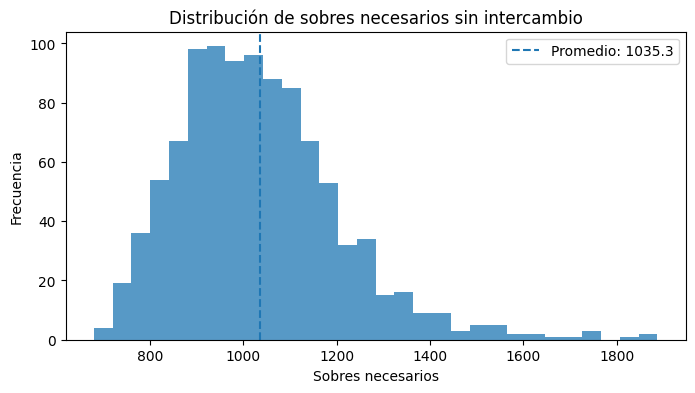

In [2]:
rng = np.random.default_rng(SEMILLA)

resultados_sin = [simular_hasta_completar(con_intercambio=False, rng=rng) for _ in range(R_COMPLETAR)]
sobres_sin = np.array([r["sobres"] for r in resultados_sin])
repetidas_sin = np.array([r["repetidas_finales"] for r in resultados_sin])

media_sin, desv_sin, li_sin, ls_sin = resumen_serie(sobres_sin)
media_rep_sin, desv_rep_sin, _, _ = resumen_serie(repetidas_sin)

tabla_p1 = pd.DataFrame({
    "Métrica": [
        "Sobres promedio para completar",
        "Desviación estándar de sobres",
        "Límite inferior IC 95%",
        "Límite superior IC 95%",
        "Costo promedio comprando sobres sueltos",
        "Repetidas finales promedio"
    ],
    "Resultado": [
        media_sin,
        desv_sin,
        li_sin,
        ls_sin,
        costo_sueltos(media_sin),
        media_rep_sin
    ]
})

display(tabla_p1)

plt.figure(figsize=(8, 4))
plt.hist(sobres_sin, bins=30, alpha=0.75)
plt.axvline(media_sin, linestyle="--", label=f"Promedio: {media_sin:.1f}")
plt.title("Distribución de sobres necesarios sin intercambio")
plt.xlabel("Sobres necesarios")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


**Interpretación.**  
Según la simulación, llenar el álbum sin intercambios requiere una cantidad bastante alta de sobres. Esto tiene sentido porque mientras más se avanza, cada vez es más difícil que salga una estampa nueva. Al inicio casi todo ayuda, pero al final salen muchas repetidas y el proceso se vuelve mucho más lento. Por eso la distribución no queda totalmente centrada, sino que hay simulaciones donde por mala suerte se necesitan muchos más sobres.


# Pregunta 2  
## ¿Cómo cambia la cantidad de sobres necesarios para completar el álbum si se utiliza un sistema de intercambio de estampas repetidas?

Aquí analizamos el efecto de intercambiar, pero usando un modelo más realista. No asumimos que cada repetida automáticamente se convierte en una faltante. En cambio, cada 50 repetidas permiten intentar un intercambio, y solo el 35% de esos intentos da una estampa que realmente falta.


,Escenario,Sobres promedio,Costo promedio en sobres sueltos
0,Sin intercambio,1035.307,9835.4165
1,Con intercambio realista,690.042,6555.3990
2,Ahorro promedio,345.265,3280.0175


Intercambios exitosos promedio: 27.03


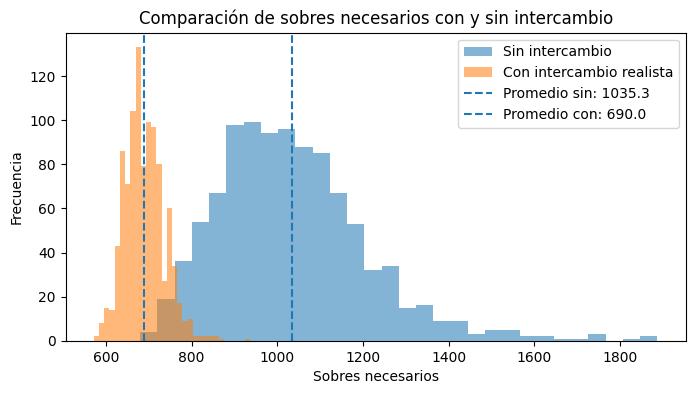

In [3]:
rng = np.random.default_rng(SEMILLA + 1)

resultados_inter = [simular_hasta_completar(con_intercambio=True, rng=rng) for _ in range(R_COMPLETAR)]
sobres_inter = np.array([r["sobres"] for r in resultados_inter])
repetidas_inter = np.array([r["repetidas_finales"] for r in resultados_inter])
intercambios_exitosos = np.array([r["intercambios_exitosos"] for r in resultados_inter])

media_inter, desv_inter, li_inter, ls_inter = resumen_serie(sobres_inter)
media_intercambios, _, _, _ = resumen_serie(intercambios_exitosos)

ahorro_sobres = media_sin - media_inter
ahorro_dinero = costo_sueltos(ahorro_sobres)

tabla_p2 = pd.DataFrame({
    "Escenario": [
        "Sin intercambio",
        "Con intercambio realista",
        "Ahorro promedio"
    ],
    "Sobres promedio": [
        media_sin,
        media_inter,
        ahorro_sobres
    ],
    "Costo promedio en sobres sueltos": [
        costo_sueltos(media_sin),
        costo_sueltos(media_inter),
        ahorro_dinero
    ]
})

display(tabla_p2)

print(f"Intercambios exitosos promedio: {media_intercambios:.2f}")

plt.figure(figsize=(8, 4))
plt.hist(sobres_sin, bins=30, alpha=0.55, label="Sin intercambio")
plt.hist(sobres_inter, bins=30, alpha=0.55, label="Con intercambio realista")
plt.axvline(media_sin, linestyle="--", label=f"Promedio sin: {media_sin:.1f}")
plt.axvline(media_inter, linestyle="--", label=f"Promedio con: {media_inter:.1f}")
plt.title("Comparación de sobres necesarios con y sin intercambio")
plt.xlabel("Sobres necesarios")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


**Interpretación.**  
El intercambio sí reduce la cantidad de sobres necesarios, pero no de forma exagerada. Este resultado se siente más lógico porque en la vida real no siempre se consigue justo la estampa que falta. Aun así, guardar repetidas y buscar intercambios puede representar un ahorro importante, especialmente en la parte final del álbum, donde comprar sobres al azar se vuelve menos eficiente.


# Pregunta 3  
## Si una persona dispone de un presupuesto limitado equivalente a 7 cajas, ¿qué tan probable es completar el álbum y cuántas estampas distintas obtiene en promedio?

En esta pregunta ya no dejamos que la simulación compre sobres hasta terminar. Ahora fijamos un presupuesto máximo de 7 cajas y revisamos qué tan cerca queda el álbum de completarse.


,Escenario,Sobres disponibles,Costo del presupuesto,Estampas distintas promedio,Faltantes promedio,Probabilidad de completar
0,Sin intercambio,728,6825.0,974.565000,5.435000,0.002500
1,Con intercambio realista,728,6825.0,979.576667,0.423333,0.790833


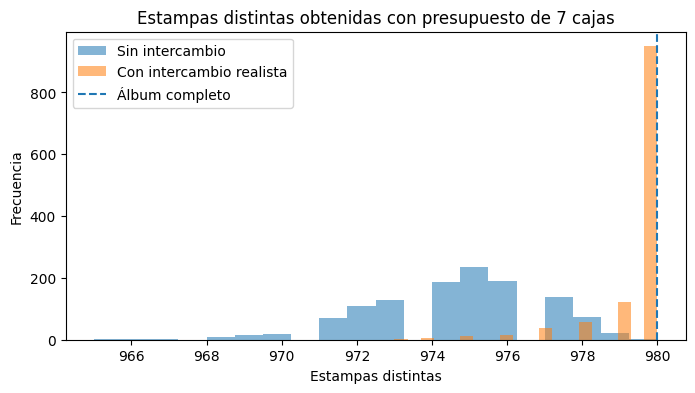

In [4]:
CAJAS_PRESUPUESTO = 7
sobres_presupuesto = CAJAS_PRESUPUESTO * SOBRES_POR_CAJA
costo_presupuesto = CAJAS_PRESUPUESTO * PRECIO_CAJA

rng = np.random.default_rng(SEMILLA + 2)

resultados_pres_sin = [
    simular_con_presupuesto(sobres_presupuesto, con_intercambio=False, rng=rng)
    for _ in range(R_PRESUPUESTO)
]

resultados_pres_inter = [
    simular_con_presupuesto(sobres_presupuesto, con_intercambio=True, rng=rng)
    for _ in range(R_PRESUPUESTO)
]

distintas_pres_sin = np.array([r["distintas"] for r in resultados_pres_sin])
distintas_pres_inter = np.array([r["distintas"] for r in resultados_pres_inter])

prob_completar_sin = np.mean(distintas_pres_sin == N)
prob_completar_inter = np.mean(distintas_pres_inter == N)

tabla_p3 = pd.DataFrame({
    "Escenario": [
        "Sin intercambio",
        "Con intercambio realista"
    ],
    "Sobres disponibles": [
        sobres_presupuesto,
        sobres_presupuesto
    ],
    "Costo del presupuesto": [
        costo_presupuesto,
        costo_presupuesto
    ],
    "Estampas distintas promedio": [
        distintas_pres_sin.mean(),
        distintas_pres_inter.mean()
    ],
    "Faltantes promedio": [
        N - distintas_pres_sin.mean(),
        N - distintas_pres_inter.mean()
    ],
    "Probabilidad de completar": [
        prob_completar_sin,
        prob_completar_inter
    ]
})

display(tabla_p3)

plt.figure(figsize=(8, 4))
plt.hist(distintas_pres_sin, bins=20, alpha=0.55, label="Sin intercambio")
plt.hist(distintas_pres_inter, bins=20, alpha=0.55, label="Con intercambio realista")
plt.axvline(N, linestyle="--", label="Álbum completo")
plt.title(f"Estampas distintas obtenidas con presupuesto de {CAJAS_PRESUPUESTO} cajas")
plt.xlabel("Estampas distintas")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


**Interpretación.**  
Con 7 cajas, el álbum queda muy avanzado, pero no necesariamente completo si no se hacen intercambios. La diferencia principal aparece cuando agregamos el intercambio realista, porque las repetidas empiezan a tener valor y ayudan a cerrar los últimos espacios. Aun así, no se puede decir que el intercambio garantice completar el álbum siempre, porque depende de la suerte y de que los intercambios realmente sean útiles.


# Pregunta 4  
## ¿Qué estrategia resulta más conveniente económicamente para completar el álbum: comprar sobres individuales o cajas completas?

Ahora comparamos el costo promedio si se compran sobres sueltos contra comprar cajas completas. Esta pregunta es útil porque aunque una caja tenga descuento, también puede obligar a comprar más sobres de los necesarios.


,Estrategia,Costo promedio,Sobres promedio relacionados
0,Sobres sueltos sin intercambio,9835.4165,1035.307
1,Cajas sin intercambio,10178.0250,1035.307
2,Sobres sueltos con intercambio,6555.3990,690.042
3,Cajas con intercambio,6971.2500,690.042


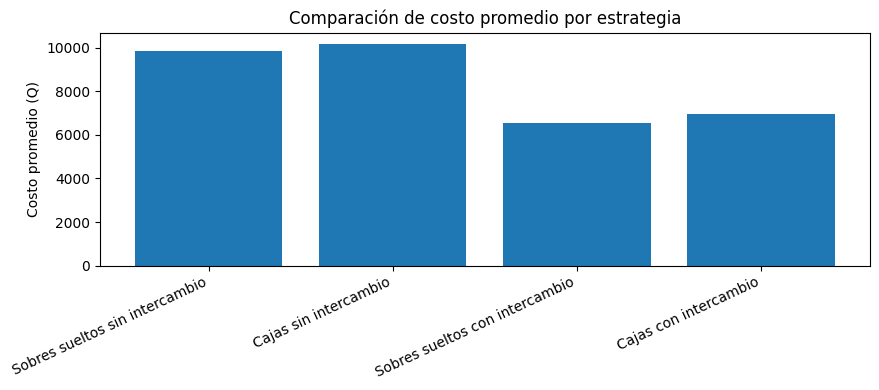

In [5]:
costos_sueltos_sin = np.array([costo_sueltos(x) for x in sobres_sin])
costos_cajas_sin = np.array([costo_por_cajas(x) for x in sobres_sin])

costos_sueltos_inter = np.array([costo_sueltos(x) for x in sobres_inter])
costos_cajas_inter = np.array([costo_por_cajas(x) for x in sobres_inter])

tabla_p4 = pd.DataFrame({
    "Estrategia": [
        "Sobres sueltos sin intercambio",
        "Cajas sin intercambio",
        "Sobres sueltos con intercambio",
        "Cajas con intercambio"
    ],
    "Costo promedio": [
        costos_sueltos_sin.mean(),
        costos_cajas_sin.mean(),
        costos_sueltos_inter.mean(),
        costos_cajas_inter.mean()
    ],
    "Sobres promedio relacionados": [
        media_sin,
        media_sin,
        media_inter,
        media_inter
    ]
})

display(tabla_p4)

plt.figure(figsize=(9, 4))
plt.bar(tabla_p4["Estrategia"], tabla_p4["Costo promedio"])
plt.title("Comparación de costo promedio por estrategia")
plt.ylabel("Costo promedio (Q)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


**Interpretación.**  
Comprar por cajas puede salir mejor que comprar sobres sueltos si se planea comprar una cantidad grande, porque el precio por sobre baja un poco. Sin embargo, la estrategia más fuerte sigue siendo combinar compras con intercambio, ya que el intercambio reduce la cantidad total de sobres necesarios. En otras palabras, la caja ayuda por precio, pero el intercambio ayuda por eficiencia.


# Pregunta 5  
## ¿Cuántos sobres se necesitan, en promedio, para alcanzar al menos el 90% del álbum completo?

Esta pregunta no busca llenar el álbum completo, sino llegar a una meta parcial. Es interesante porque llegar al 90% suele ser mucho más fácil que completar el 100%, ya que el problema fuerte aparece con las últimas estampas.


,Escenario,Sobres promedio para llegar al 90%,Costo promedio en sobres sueltos,IC 95% inferior,IC 95% superior
0,Sin intercambio,321.899167,3058.042083,321.257990,322.540344
1,Con intercambio realista,315.983333,3001.841667,315.385129,316.581538


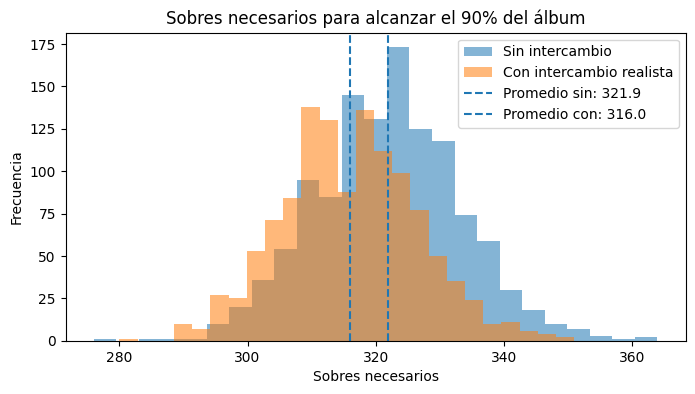

In [6]:
PORCENTAJE_OBJETIVO = 0.90

rng = np.random.default_rng(SEMILLA + 3)

resultados_90_sin = [
    simular_hasta_porcentaje(PORCENTAJE_OBJETIVO, con_intercambio=False, rng=rng)
    for _ in range(R_90)
]

resultados_90_inter = [
    simular_hasta_porcentaje(PORCENTAJE_OBJETIVO, con_intercambio=True, rng=rng)
    for _ in range(R_90)
]

sobres_90_sin = np.array([r["sobres"] for r in resultados_90_sin])
sobres_90_inter = np.array([r["sobres"] for r in resultados_90_inter])

media_90_sin, desv_90_sin, li_90_sin, ls_90_sin = resumen_serie(sobres_90_sin)
media_90_inter, desv_90_inter, li_90_inter, ls_90_inter = resumen_serie(sobres_90_inter)

tabla_p5 = pd.DataFrame({
    "Escenario": [
        "Sin intercambio",
        "Con intercambio realista"
    ],
    "Sobres promedio para llegar al 90%": [
        media_90_sin,
        media_90_inter
    ],
    "Costo promedio en sobres sueltos": [
        costo_sueltos(media_90_sin),
        costo_sueltos(media_90_inter)
    ],
    "IC 95% inferior": [
        li_90_sin,
        li_90_inter
    ],
    "IC 95% superior": [
        ls_90_sin,
        ls_90_inter
    ]
})

display(tabla_p5)

plt.figure(figsize=(8, 4))
plt.hist(sobres_90_sin, bins=25, alpha=0.55, label="Sin intercambio")
plt.hist(sobres_90_inter, bins=25, alpha=0.55, label="Con intercambio realista")
plt.axvline(media_90_sin, linestyle="--", label=f"Promedio sin: {media_90_sin:.1f}")
plt.axvline(media_90_inter, linestyle="--", label=f"Promedio con: {media_90_inter:.1f}")
plt.title("Sobres necesarios para alcanzar el 90% del álbum")
plt.xlabel("Sobres necesarios")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


**Interpretación.**  
Llegar al 90% del álbum requiere muchos menos sobres que completar el álbum. Esto confirma una idea importante de la simulación: el problema no es conseguir la mayoría de estampas, sino conseguir las últimas. Por eso muchas personas pueden sentir que ya casi terminaron el álbum, pero aun así les falta gastar bastante si quieren llegar al 100%.
